# 06 — Uncertainty & sensitivity analysis

**Which of the inputs actually decides where the priorities land?** `03`/`04` answer *where* the
priorities are; this notebook answers *what drives them*, by solving the same problem many times
under perturbed parameters and attributing the movement to individual factors.

Post-solve by design — it consumes the same aligned stack as `03`, but re-runs the optimizer
rather than reading one result.

**Phases** (see the plan / `CLAUDE.md`):
- **2** — ensemble runner: solve a design matrix, resumably, N solves at a time
- **2.5** — solver noise floor: the guard that says whether an effect is signal
- **3** — Morris screening: rank all 12 factors by μ*, plus per-cell μ* maps

Everything runs at **2 km** (`ENSEMBLE["agg_factor"]`) while the headline stays 1 km, so **G2
below checks that 2 km conclusions transfer** before the batch is worth running.

**Kernel:** `Python (y2y-geo)`. Ethan runs cell-by-cell; the batch cells are long-running and
**resumable** — re-running one picks up where it stopped.

In [5]:
# ---- Setup ---------------------------------------------------------------
import importlib
import numpy as np
import pandas as pd
import geopandas as gpd

import config, ensemble_core as ec
importlib.reload(config); importlib.reload(ec)

FIG = config.PROJECT_DIR / "figures"
OUTLINE = gpd.read_file(config.CORRIDOR_REF).to_crs(config.TARGET_CRS)
E = config.ENSEMBLE
print(f"analysis={E['analysis']} | {E['workers']} workers x {E['threads']} threads "
      f"| agg={E['agg_factor']} ({config.TARGET_RES_M*E['agg_factor']/1000:.0f} km) "
      f"| time limit {E['time_limit']}s")
print(f"factors: {len(config.MORRIS['factors'])} | Morris r={config.MORRIS['r']} "
      f"-> {config.MORRIS['r']*(len(config.MORRIS['factors'])+1)} runs")

analysis=y2y | 3 workers x 3 threads | agg=2 (2 km) | time limit 21600s
factors: 12 | Morris r=10 -> 130 runs


## Gate 1 — equivalence: does the headless driver reproduce the notebook?

`run_one.R` mirrors `03a` cells 1–9. Before trusting 145 unattended solves, prove one run through
the driver reproduces a run through the notebook. This solves the **unmodified baseline at 1 km**
and compares against `iter5_lp_1km_neighbor` — same planning units, same budget, and a selected-set
Jaccard of 1.0. Expect ~77 min (this is the only 1 km solve in the notebook).

In [6]:
# ---- G1: equivalence check vs the existing 1 km headline (one solve) ----
# SETTINGS matter here: this is a single GATE solve, not an ensemble run, so it gets the full
# 1 km grid, EVERY core (threads=0 -> R falls back to detectCores()) and the full config
# time limit. Inheriting the ensemble's 3-thread slice + 2 h stuck-run guard would risk a
# spurious timeout on a solve that took 4,591 s at 10 threads -- a G1 "failure" that says
# nothing about driver equivalence.
eq_design = ec.noise_floor_design(n=1)          # a single unperturbed row
eq_manifest, _ = ec.base_manifest("equiv_check")
ec.run(eq_design, "equiv_check", manifest=eq_manifest,
       overrides_fn=lambda r, m: ec.baseline_overrides(m),
       workers=1,
       settings={"agg_factor": 1, "threads": 0, "time_limit": config.SOLVER_TIME_LIMIT})

[equiv_check] 1 rows | 1 already done (skipped) | 0 to solve
[equiv_check] complete: 1/1


,run_id,done
0,0,True


In [7]:
# ---- G1 verdict: compare against output_data/iter5_lp_1km_neighbor ----
import json, rasterio
new = ec._alloc(config.RESULTS_DIR / "equiv_check" / "run_0000" / "portfolio.tif")
old = ec._alloc(config.RESULTS_DIR / "iter5_lp_1km_neighbor" / "portfolio.tif")
s_new, s_old = new > E["select_threshold"], old > E["select_threshold"]
j = float((s_new & s_old).sum() / max((s_new | s_old).sum(), 1))
a = json.loads((config.RESULTS_DIR / "equiv_check" / "run_0000" / "run_summary.json").read_text())
b = json.loads((config.RESULTS_DIR / "iter5_lp_1km_neighbor" / "run_summary.json").read_text())
for k in ("n_planning_units", "budget_cells", "n_locked_in"):
    print(f"  {k:20s} driver={a[k]:>12,}  notebook={b[k]:>12,}  {'OK' if a[k]==b[k] else 'MISMATCH'}")
print(f"\n  selected-set Jaccard = {j:.6f}  ({'EQUIVALENT' if j > 0.999 else 'DIVERGED -- stop'})")

  n_planning_units     driver=   1,272,914  notebook=   1,272,914  OK
  budget_cells         driver=     381,874  notebook=     381,874  OK
  n_locked_in          driver=     191,029  notebook=     191,029  OK

  selected-set Jaccard = 1.000000  (EQUIVALENT)


## Gate 2 — scale transfer: do 2 km conclusions carry to the 1 km headline?

The screening runs at 2 km for tractability, but the published map is 1 km. If the 2 km baseline
does not reproduce the 1 km priorities, nothing learned at 2 km transfers and the design needs
rethinking. (`iter4_lp_2km_compact` cannot serve as this baseline — it used the *boundary* penalty
and predates `neighbor_penalty`.)

In [8]:
# ---- G2: fresh 2 km baseline, compared to the 1 km headline ----
# Also a single gate solve -> all cores. Stays at the ensemble's 2 km, since the whole point is
# to check that THIS resolution stands in for the 1 km headline. It doubles as the reference
# run that `dissim_vs_base` is measured against in Phase 3.
base_design = ec.noise_floor_design(n=1)
base_manifest, _ = ec.base_manifest("baseline_2km")
ec.run(base_design, "baseline_2km", manifest=base_manifest,
       overrides_fn=lambda r, m: ec.baseline_overrides(m),
       workers=1, settings={"threads": 0, "time_limit": config.SOLVER_TIME_LIMIT})

[baseline_2km] 1 rows | 1 already done (skipped) | 0 to solve
[baseline_2km] complete: 1/1


,run_id,done
0,0,True


In [9]:
# ---- G2 verdict: 2 km vs 1 km priority agreement ----
import rioxarray
b2 = rioxarray.open_rasterio(config.RESULTS_DIR/"baseline_2km"/"run_0000"/"portfolio.tif", masked=True).squeeze()
b1 = rioxarray.open_rasterio(config.RESULTS_DIR/"iter5_lp_1km_neighbor"/"portfolio.tif", masked=True).squeeze()
b1m = b1.rio.reproject_match(b2)                      # 1 km -> the 2 km grid for comparison
x, y = (b2.values > E["select_threshold"]), (b1m.values > E["select_threshold"])
print(f"2 km vs 1 km selected-set Jaccard = {float((x & y).sum() / max((x | y).sum(),1)):.3f}")
print("  >0.8 = screening conclusions transfer | <0.6 = they do not, reconsider the design")

2 km vs 1 km selected-set Jaccard = 0.833
  >0.8 = screening conclusions transfer | <0.6 = they do not, reconsider the design


## Phase 2.5 — solver noise floor

`OPT_GAP = 0.10` means solutions are not proven optimal, so identical re-solves *can* differ.
Morris effects are **differences between paired runs** — if solver noise is the size of a real
perturbation, the whole ranking is noise. Ten identical runs, at the **same** workers/threads the
real batch uses (thread count can change where an interior-point solve stops).

If the floor is ~0, all downstream variance is attributable to inputs. If it is material, tighten
`OPT_GAP` and re-baseline **before** spending the batch.

In [10]:
# ---- Phase 2.5: 10 identical solves ----
# Runs at the ENSEMBLE defaults deliberately: the floor must be measured at the same
# workers x threads the real batch uses, because thread count can itself change where an
# interior-point solve stops. A floor measured on a single full-core run would not transfer.
noise_design = ec.noise_floor_design(n=10)
ec.run(noise_design, "noise_floor", overrides_fn=lambda r, m: ec.baseline_overrides(m))

[noise_floor] 10 rows | 10 already done (skipped) | 0 to solve
[noise_floor] complete: 10/10


,run_id,done
0,0,True
1,1,True
2,2,True
3,3,True
4,4,True
5,5,True
6,6,True
7,7,True
8,8,True
9,9,True


In [11]:
# ---- Noise floor verdict ----
noise_df, noise_A, _ = ec.collect("noise_floor", noise_design)
FLOOR = ec.noise_report(noise_A, tag="noise_floor")

[noise_floor] collected 10 runs | domain 330,481 cells
SOLVER NOISE FLOOR [noise_floor] -- 10 identical re-solves
  pairwise Jaccard of the selected set : min 1.000000  mean 1.000000
  per-cell allocation SD               : max 0.000000  mean 0.000000
  cells that ever flip selection       : 0

  -> noise floor (max dissimilarity between identical runs) = 0.000000
     Solver is DETERMINISTIC here -- all downstream variance is attributable to inputs.


## Phase 3 — Morris screening

Ranks **all 12 factors** — the 8 continuous feature weights, the EFG group weight, `budget_pct`,
`target_pct`, `neighbor_penalty` — by how far each moves the selected set. `r=10` trajectories ×
(k+1) = **130 solves**, resumable.

The climate scenario is deliberately not a factor (it would need shared-anchor orientation plus a
headline re-solve — deferred with Phase 1b).

Two readouts: **μ\*** = influence (the ranking) and **σ** = how much a factor's influence depends
on the others. Note `min_shortfall` is scale-invariant in the weights, so scaling all nine
together is a null direction — it correctly shows no effect.

**Reference map.** `dissim_vs_base` is measured against the *unperturbed* 2 km baseline
(`baseline_2km`, every multiplier 1.0) — the one run whose parameters are `config.py`'s own.
It is solved outside this batch on purpose.

**Read μ\* and σ, not μ.** Because the metric is a *distance from a reference*, the response
surface is V-shaped in every factor (moving toward the baseline lowers dissimilarity, moving
past it raises it again). Signed μ therefore only reports which side of the baseline the
trajectory steps happened to fall on, and the same V-shape inflates σ — so a high σ/μ\* here is
not by itself evidence of factor interaction. Weigh that before reading the Phase 4 gate below.


In [12]:
# ---- Morris design (deterministic: seeded in config.MORRIS) ----
design, prob, X = ec.morris_design()
design.head()

Morris design: r=10 trajectories x (k+1)=13 = 130 runs | num_levels=4 seed=20260730


,run_id,w_human_modification,w_transboundary_connectivity,w_climate_corridors,w_climate_type_macrorefugia,w_irrecoverable_carbon_biomass,w_irrecoverable_carbon_m_soc,w_aoh_richness_mammals,w_aoh_richness_birds,w_EFG_group,budget_pct,target_pct,neighbor_penalty,kind
0,0,2.0,-0.666667,2.0,-2.0,-2.0,0.666667,0.666667,0.666667,0.666667,0.266667,0.5,-4.666667,morris
1,1,2.0,-0.666667,2.0,-2.0,-2.0,0.666667,0.666667,0.666667,-2.000000,0.266667,0.5,-4.666667,morris
2,2,2.0,-0.666667,2.0,-2.0,-2.0,0.666667,0.666667,0.666667,-2.000000,0.266667,0.5,-6.000000,morris
3,3,2.0,-0.666667,2.0,-2.0,-2.0,0.666667,-2.000000,0.666667,-2.000000,0.266667,0.5,-6.000000,morris
4,4,2.0,-0.666667,2.0,-2.0,-2.0,0.666667,-2.000000,0.666667,-2.000000,0.400000,0.5,-6.000000,morris


In [13]:
# ---- Phase 3: the batch (130 solves; long-running and RESUMABLE) ----
ec.run(design, "morris")

[morris] 130 rows | 130 already done (skipped) | 0 to solve
[morris] complete: 130/130


,run_id,done
0,0,True
1,1,True
2,2,True
3,3,True
4,4,True
...,...,...
125,125,True
126,126,True
127,127,True
128,128,True


In [14]:
# ---- Collect + primary metric ----
# The reference for `dissim_vs_base` is the UNPERTURBED baseline solve (the G2 run above),
# NEVER a row of this batch -- see ensemble_core.add_baseline_metrics for what goes wrong
# when it is (it silently measures every run against an arbitrary design corner, and it moves
# the mu* ranking). Metric only, no re-solving, so this cell is cheap to re-run.
res, A, domain = ec.collect("morris", design)
res = ec.add_baseline_metrics(res, A, domain)
print(f"noise floor for comparison: {FLOOR:.6f}  (0 -> every effect below is signal, not noise)")
print("NOTE the design never sits AT the baseline: with num_levels=4 the sampled levels are")
print("0, 1/3, 2/3, 1 of each range while every baseline value is at 0.5, so dissim has a")
print("positive floor. Fine for screening; the ABSOLUTE level is not 'distance from the map'.")

[morris] collected 130 runs | domain 330,481 cells
reference = baseline_2km/run_0000 (unperturbed) | 99,190 selected cells | dissim over the batch: 0.221 .. 0.550
noise floor for comparison: 0.000000  (0 -> every effect below is signal, not noise)
NOTE the design never sits AT the baseline: with num_levels=4 the sampled levels are
0, 1/3, 2/3, 1 of each range while every baseline value is at 0.5, so dissim has a
positive floor. Fine for screening; the ABSOLUTE level is not 'distance from the map'.


In [15]:
# ---- VALIDITY CHECK: total selected area must track budget_pct and little else ----
# A deliberate self-test. If some other factor moves the selected area, the design or the
# manifest patching is wrong -- diagnose before reading anything else.
area_tbl = ec.analyze_morris(res, X, "pct_region", prob)
top = area_tbl.iloc[0]
print(f"\ntop driver of selected area = {top.factor} "
      f"({'EXPECTED' if top.factor == 'budget_pct' else 'UNEXPECTED -- investigate'})")


MORRIS -- effects on `pct_region` (mu* = influence, sigma = interaction/nonlinearity)
                        factor  mu_star   mu  sigma  mu_star_conf
                    budget_pct     20.0 20.0    0.0           0.0
          w_human_modification      0.0  0.0    0.0           0.0
  w_transboundary_connectivity      0.0  0.0    0.0           0.0
           w_climate_corridors      0.0  0.0    0.0           0.0
   w_climate_type_macrorefugia      0.0  0.0    0.0           0.0
w_irrecoverable_carbon_biomass      0.0  0.0    0.0           0.0
  w_irrecoverable_carbon_m_soc      0.0  0.0    0.0           0.0
        w_aoh_richness_mammals      0.0  0.0    0.0           0.0
          w_aoh_richness_birds      0.0  0.0    0.0           0.0
                   w_EFG_group      0.0  0.0    0.0           0.0
                    target_pct      0.0  0.0    0.0           0.0
              neighbor_penalty      0.0  0.0    0.0           0.0

top driver of selected area = budget_pct (EXPECTED)



MORRIS -- effects on `dissim_vs_base` (mu* = influence, sigma = interaction/nonlinearity)
                        factor  mu_star      mu  sigma  mu_star_conf
w_irrecoverable_carbon_biomass   0.1024 -0.0585 0.1036        0.0272
                    budget_pct   0.0886  0.0353 0.1001        0.0309
              neighbor_penalty   0.0710 -0.0416 0.0789        0.0276
  w_irrecoverable_carbon_m_soc   0.0707 -0.0465 0.0718        0.0247
                   w_EFG_group   0.0450 -0.0303 0.0485        0.0187
                    target_pct   0.0310  0.0091 0.0429        0.0171
           w_climate_corridors   0.0232  0.0032 0.0307        0.0111
  w_transboundary_connectivity   0.0230  0.0046 0.0306        0.0098
        w_aoh_richness_mammals   0.0106  0.0023 0.0148        0.0061
          w_aoh_richness_birds   0.0085  0.0057 0.0119        0.0057
          w_human_modification   0.0068  0.0041 0.0097        0.0043
   w_climate_type_macrorefugia   0.0026  0.0011 0.0052        0.0026
cross-check 

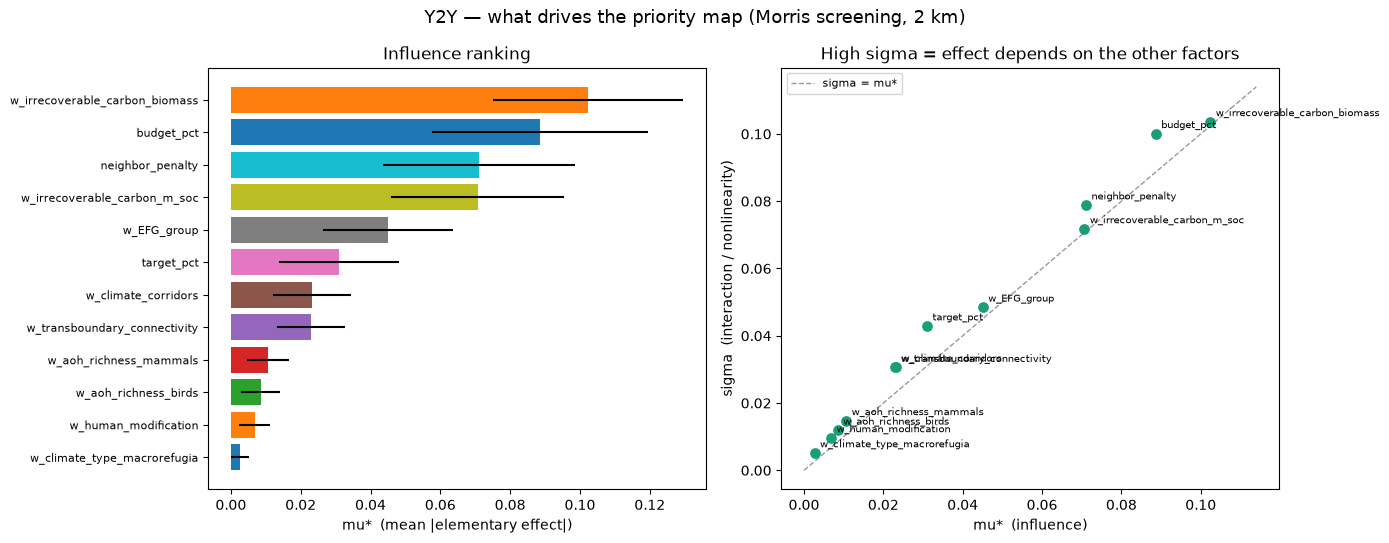

In [16]:
# ---- THE HEADLINE: which inputs drive the priorities? ----
morris_tbl = ec.analyze_morris(res, X, "dissim_vs_base", prob)
ec.cross_check(X, res, prob)          # our per-cell math == SALib's, else the maps are unsafe
ec.plot_morris(morris_tbl, "Y2Y — what drives the priority map (Morris screening, 2 km)",
               fname="morris_screening.png", fig_dir=FIG)

In [17]:
# ---- Per-input view: which factor changes how much of each input we capture ----
held = [c for c in res.columns if c.startswith("held_")]
rows = []
for h in held:
    t = ec.analyze_morris(res, X, h, prob)
    rows.append(dict(objective=h.replace("held_", ""), top_factor=t.iloc[0].factor,
                     mu_star=t.iloc[0].mu_star, second=t.iloc[1].factor))
pd.DataFrame(rows)


MORRIS -- effects on `held_human_modification` (mu* = influence, sigma = interaction/nonlinearity)
                        factor  mu_star      mu  sigma  mu_star_conf
                    budget_pct   0.1981  0.1981 0.0063        0.0039
                   w_EFG_group   0.0069 -0.0069 0.0060        0.0034
  w_irrecoverable_carbon_m_soc   0.0041  0.0041 0.0031        0.0021
           w_climate_corridors   0.0026  0.0026 0.0021        0.0013
w_irrecoverable_carbon_biomass   0.0021 -0.0015 0.0025        0.0011
  w_transboundary_connectivity   0.0020  0.0020 0.0018        0.0010
                    target_pct   0.0015  0.0001 0.0021        0.0009
              neighbor_penalty   0.0013  0.0000 0.0020        0.0009
          w_aoh_richness_birds   0.0011 -0.0011 0.0006        0.0004
          w_human_modification   0.0009  0.0009 0.0008        0.0005
        w_aoh_richness_mammals   0.0004 -0.0004 0.0005        0.0003
   w_climate_type_macrorefugia   0.0003 -0.0001 0.0005        0.0003

MO

,objective,top_factor,mu_star,second
0,human_modification,budget_pct,0.198093,w_EFG_group
1,transboundary_connectivity,budget_pct,0.226366,w_transboundary_connectivity
2,climate_corridors,budget_pct,0.203300,w_EFG_group
3,climate_type_macrorefugia,budget_pct,0.202313,w_irrecoverable_carbon_m_soc
4,irrecoverable_carbon_biomass,budget_pct,0.310372,w_irrecoverable_carbon_biomass
5,irrecoverable_carbon_m_soc,w_irrecoverable_carbon_m_soc,0.282603,budget_pct
6,aoh_richness_mammals,budget_pct,0.209185,w_irrecoverable_carbon_m_soc
7,aoh_richness_birds,budget_pct,0.215835,w_irrecoverable_carbon_m_soc
8,EFG_mean,w_EFG_group,0.171074,budget_pct


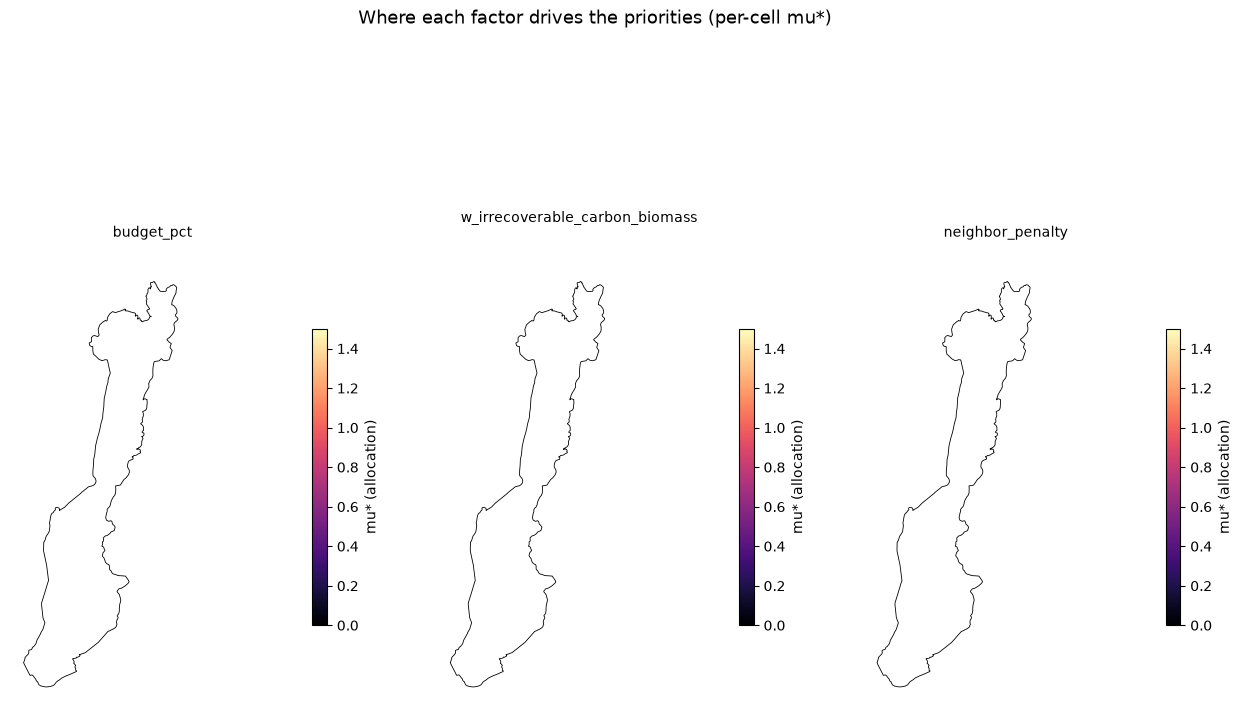

In [18]:
# ---- Per-cell mu*: WHERE each factor decides ----
mu, n_eff = ec.per_cell_mu_star(X, A, prob)
ec.plot_mu_star_maps(mu, domain, prob["names"], top=3, fig_dir=FIG, outline=OUTLINE)

## Phase 3 → 4 gate

Read off the table above:

- **How many factors clear the noise floor?** Those are the ones that matter; the rest are
  reportable as "priorities are insensitive to X".
- **2–3 survivors** → a crossed factorial over them is cheaper than Sobol' and reads better to a
  conservation audience.
- **5+ survivors with high σ** (strong interactions) → a factorial cannot summarise them and
  Sobol' earns its ~4 extra days.

Record the decision in `CLAUDE.md` before running Phase 4.